# Analyse stimulus history of EW2 recordings

Requires information from stimulus log file and recording field positions from `.smh`header files; for this specific analysis, the data is already consolidated in a `.cvs`file (see below).

In [42]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [164]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib import colors
import numpy as np

import stim_outlines
import stim_movies

In [44]:
CONSOL_PATH = Path("../data/experiment-overview_consolidated.csv")
STIM_MOV_PATH = Path("../data/stimuli-as-movies")
STIM_MOV_EXT = ".pickle" 

## Generate a map of the stimulus presentation


**(1) Area illuminated by the different stimuli**

Get illuminated area and mean illumination for the stimuli.   
Note that it would be better to get the parameters directly from `stims`, but here we just use the most important stimulus parameters for an estimate.


In [45]:
# Approx. field of view of stimulus through objective lens
# ESTIMATED: CHECK!
#FOV_diam = 1500  # Nikon 16x objective (CF175 LWD×16/0.8W, DIC N2)
FOV_diam = 1000   # W Plan-Apochromat 20x/1,0 DIC M27, Zeiss

# Create shapes (=areas illuminated by the stimuli)
MovingBar = dict(
    {'barDx_um': 1000.0, 
     'barDy_um': 300.0, 
     'nTrials': 3, 
     'vel_umSec': 1000.0, 
     'tMoveDur_s': 4.0, 
     'DirList': [0, 180, 45, 225, 90, 270, 135, 315], 
     'barColor': (255, 255, 255), 
     'bkgColor': (0, 0, 0)}
)
lEdge = MovingBar["barDy_um"]
trajLen = MovingBar["tMoveDur_s"] *MovingBar["vel_umSec"] +MovingBar["barDx_um"]
mb = stim_outlines.movingBar(lEdge, trajLen, MovingBar["DirList"], FOV_diam=FOV_diam)

RGC_Chirp = dict(
    {'tSteadyON_s': 3.0, 
     'tSteadyOFF2_s': 2.0, 
     'tSteadyMID_s': 2.0, 
     'chirpMaxFreq_Hz': 8.0, 
     'tSteadyOFF_s': 3.0, 
     'ContrastFreq_Hz': 2.0, 
     'nTrials': 5, 
     'dxStim_um': 1000, 
     'IHalf': 127, 
     'chirpDur_s': 8.0, 
     'IFull': 254}
)
chirp = stim_outlines.spot(diam=RGC_Chirp["dxStim_um"], FOV_diam=FOV_diam)

MouseCam_Left = dict(
    {'movparams_Train': {'nFr': 16200, 'dyFr': 56, 'dxFr': 56}, 
     'movName_Train': '//Katrin//RGCs//train_images_right.jpg', 
     'nFrRepeats': 2, 
     'movparams_Test': {'nFr': 750, 'dyFr': 56, 'dxFr': 56}, 
     'FrameRateMovie': 30.0, 
     'movName_Test': '//Katrin//RGCs//test_images_rand_right.jpg', 
     'movScale': (12.5, 12.5), 
     'movAlpha': 255, 
     'movOrient': 0, 
     'nFrPerMarker': 3, 
     'IndexName': 'RandomSequences', 
     'nTrials': 1, 
     'durSnippet_s': 5.0}
)
dx = MouseCam_Left["movparams_Train"]["dxFr"] *MouseCam_Left["movScale"][0]
dy = MouseCam_Left["movparams_Train"]["dyFr"] *MouseCam_Left["movScale"][1]
mouseMovie = stim_outlines.box(dx, dy, FOV_diam=FOV_diam)


**(2) Get stimulus sequence and recording positions**

Load currated file with stimulus and recording data.

Bringing together the data from the `.smh` files and the stimulus log file automatically is currently tricky, as the data here was recorded on two PCs with not well synchronized clocks. This needs to be done (e.g., sync time to time server automatically) in future experiments. Also, it would be good to record the scan position in the QDSpy `.log` file to have the field positions also for focus scans (where no recording file is written).


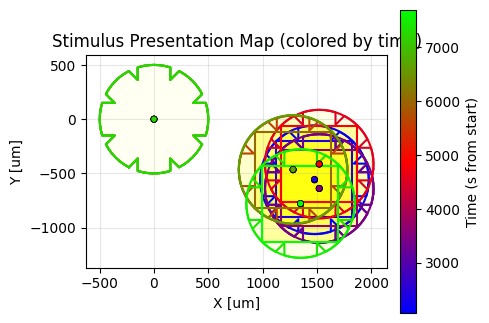

In [46]:
df = pd.read_csv(CONSOL_PATH, on_bad_lines='warn', sep=';')

# Create figure for plotting
fig, ax = plt.subplots(figsize=(5, 5))

# Get time range for colormap normalization (only for rows with position data)
df_with_pos = df[df['pos_xyz'].notna()].copy()
if len(df_with_pos) > 0:
    t_min = df_with_pos['t_abs_s'].min()
    t_max = df_with_pos['t_abs_s'].max()
else:
    t_min, t_max = 0, 1

# Create colormap (using 'brg' - blue-red-green)
norm = Normalize(vmin=t_min, vmax=t_max)
cmap = cm.brg

# The alpha value equivalent to 1 sec stimulus exposure
alpha_per_s = 0.001

for index, row in df.iterrows():
    # Get coordinates 
    if row["pos_xyz"] is not np.nan:
        s = row["pos_xyz"][1:-1].split(",")
        pos_xyz = [float(s[i]) for i in range(len(s))]
    else:
        pos_xyz = None    

    # Get other parameters
    fStimName = row["stimFileName"]
    fRecName = "" if row["dataFileName"] is np.nan else row["dataFileName"]
    t_abs_s = row["t_abs_s"]
    t_dur_s = row["t_dur_s"]
    '''
    print(f"{row["index"]:3d} {fStimName:32s} {fRecName:30s} {pos_xyz}")
    '''

    if pos_xyz:
        # Plot stimuli only for presentations w/ position data
        x0, y0 = pos_xyz[0], pos_xyz[1]
        
        # Get color based on time
        edge_color = cmap(norm(t_abs_s))
        
        if fStimName.upper() in ["DS"]:
            # Plot moving bar outline at the current position
            poly = stim_outlines.movingBar(lEdge, trajLen, MovingBar["DirList"], x0=x0, y0=y0, FOV_diam=FOV_diam)
            x, y = poly.exterior.xy

            # Adjusting exposure to presentation duration and mean intensity (estimate)
            # TODO: Better estimate
            expos = min(1, t_dur_s *alpha_per_s *0.2)
            
            # Fill first (lower z-order), outline on top (higher z-order)
            ax.fill(x, y, color='yellow', alpha=expos, zorder=1)
            ax.plot(x, y, color=edge_color, linewidth=1.5, zorder=5)

        elif fStimName in ["Chirp"]:
            # Plot chirp outline at the current position
            poly = stim_outlines.spot(diam=RGC_Chirp["dxStim_um"], x0=x0, y0=y0, FOV_diam=FOV_diam)
            x, y = poly.exterior.xy

            # Adjusting exposure to presentation duration and mean intensity (estimate)
            # TODO: Better estimate
            expos = min(1, t_dur_s *alpha_per_s *0.5)
            
            # Fill first (lower z-order), outline on top (higher z-order)
            ax.fill(x, y, color='yellow', alpha=expos, zorder=1)
            ax.plot(x, y, color=edge_color, linewidth=1.5, zorder=5)

        elif fStimName in ["MouseCam_Right"]:
            # Plot movie outline at the current position
            poly = stim_outlines.box(dx, dy, x0=x0, y0=y0, FOV_diam=FOV_diam)
            x, y = poly.exterior.xy

            # Adjusting exposure to presentation duration and mean intensity (estimate)
            # TODO: Better estimate
            expos = min(1, t_dur_s *alpha_per_s *0.5)
            
            # Fill first (lower z-order), outline on top (higher z-order)
            ax.fill(x, y, color='yellow', alpha=expos, zorder=1)
            ax.plot(x, y, color=edge_color, linewidth=1.5, zorder=5)

# Add scatter points for recording positions
df_valid = df[df['pos_xyz'].notna()].copy()
df_valid['x'] = df_valid['pos_xyz'].apply(lambda v: float(v[1:-1].split(',')[0]))
df_valid['y'] = df_valid['pos_xyz'].apply(lambda v: float(v[1:-1].split(',')[1]))
sc = ax.scatter(df_valid['x'], df_valid['y'], c=df_valid['t_abs_s'], cmap='brg', 
                s=20, marker='o', zorder=10, edgecolor='k', linewidth=0.5)

# Add colorbar with same height as the plot
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Time (s from start)')

ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
ax.set_title('Stimulus Presentation Map (colored by time)')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Generate a map of the stimulus presentation (using movies)

### Load stimulus movie files into numpy array

... and zero blue channel, as it was not used (green=G, red=UV?)

In [47]:
# Load movie files and zero blue channel
tmp_path = Path.joinpath(STIM_MOV_PATH, "RGC_MovingBar" +STIM_MOV_EXT)
mov_DS = stim_movies.load_qdspy_movie(tmp_path)
mov_DS[:,:,:,2] = 0

tmp_path = Path.joinpath(STIM_MOV_PATH, "RGC_Chirp" +STIM_MOV_EXT)
mov_Chirp = stim_movies.load_qdspy_movie(tmp_path)
mov_Chirp[:,:,:,2] = 0

tmp_path = Path.joinpath(STIM_MOV_PATH, "MouseCam_Left" +STIM_MOV_EXT)
mov_MouseCamLeft = stim_movies.load_qdspy_movie(tmp_path)
mov_MouseCamLeft[:,:,:,2] = 0

Loading pickle file from: ..\data\stimuli-as-movies\RGC_MovingBar.pickle
Done.
Loading pickle file from: ..\data\stimuli-as-movies\RGC_Chirp.pickle
Done.
Loading pickle file from: ..\data\stimuli-as-movies\MouseCam_Left.pickle
Done.


### Define some global settings and field positions

In [166]:
# Define spatial and temporal scaling (approximated, see TODOs)
# (pixel size from moving bar width / bar pixels in movies)
_, dx, dy, _ = mov_DS.shape
px_um = 300 /7
params = dict({
    "pix_size_um": 300 /7,  # moving bar width / bar pixels in movies
    "mov_dxy": [dx, dy],
    "mov_dxy_um": [px_um *dx, px_um *dy],
    "dt_fr_s": 1 /60,
    "nCh": 2,
    "rec_field_dxy_um": [95, 95],
    "surr_factor": 1.5,    
    "sel_chan": "Green",
    "tau_adapt_s": 60*3
})

# Define field locations (and colors for plot)
fields = [
    {"field": 0, "pos_xy_um": [1478.2,-557.4]},
    {"field": 1, "pos_xy_um": [1522.4,-637.8]},
    {"field": 2, "pos_xy_um": [1522.4,-413.8]},
    {"field": 3, "pos_xy_um": [1281.6,-464.0]},
    {"field": 4, "pos_xy_um": [1350.0,-777.0]}
]
''' 
field_colors = plt.cm.tab10(np.linspace(0, 0.9, len(fields)))
'''
field_colors = [
    colors.to_rgba("coral"),
    colors.to_rgba("goldenrod"),
    colors.to_rgba("seagreen"),
    colors.to_rgba("dodgerblue"),
    colors.to_rgba("slateblue")
]


### Functions to generate exposure spatio-temporal plots

`calc_spatial_exposure` extract exposure data for the given range of stimulus presentations (as lines in the consolidated stimulus protocol file `fLogConsol`). The function generates the plot as well as a structure `movie_data`, which contains for every line in the stimulus protocol the exposure movie.   

`calc_temporal_exposure` calculates from `_mov_data` the temporal exposure traces (mean and cumulative intensity) and plot them, if required

In [184]:
def calc_spatial_exposure(
        fLogConsol: Path, _p: dict, ln_range: list =[0, 1000], 
        _plot: bool =True, _verbose: bool =True        
    ):
    """ Generate exposure data for the given range of stimulus presentations 
        (as lines in the consolidated stimulus protocol file `fLogConsol`)
        The function generates the plot as well as a structure `movie_data`, which contains 
        for every line in the stimulus protocol the exposure movie. 
    """    
    # Read consolidated experiment protocol
    df = pd.read_csv(fLogConsol, on_bad_lines='warn', sep=';')

    # Get some general parameters
    nCh = _p["nCh"]

    # Recording field size and factor by which to increase recording field area
    # for intensity exposure traces
    rec_field_dxy_um = _p["rec_field_dxy_um"]
    surr_factor = _p["surr_factor"]    

    # Determine the extent of the experiment area to create accumulator array
    df_valid = df[df['pos_xyz'].notna()].copy()
    df_valid['x'] = df_valid['pos_xyz'].apply(lambda v: float(v[1:-1].split(',')[0]))
    df_valid['y'] = df_valid['pos_xyz'].apply(lambda v: float(v[1:-1].split(',')[1]))

    # Set fixed bounds for the display area
    x_min = 500
    x_max = 2250
    y_min = -1250
    y_max = 250

    # Create accumulator array for the summary picture
    pix_size_um = _p["pix_size_um"]
    acc_width_px = int((x_max - x_min) / pix_size_um)
    acc_height_px = int((y_max - y_min) / pix_size_um)
    acc_image = np.zeros((acc_height_px, acc_width_px, _p["nCh"]), dtype=np.float64)
    if _verbose:
        print(f"Accumulator image size: {acc_width_px} x {acc_height_px} pixels")
        print(f"Spatial extent: X=[{x_min:.1f}, {x_max:.1f}] um, Y=[{y_min:.1f}, {y_max:.1f}] um")

    # Create variables to hold arrays for intensity-time plots
    movie_data = []
    
    for index, row in df.iterrows():
        # Restrict to part of the experiment
        if index < ln_range[0] or index > ln_range[1]:
            continue

        # Get coordinates 
        if row["pos_xyz"] is not np.nan:
            s = row["pos_xyz"][1:-1].split(",")
            pos_xyz = [float(s[i]) for i in range(len(s))]
        else:
            pos_xyz = None    

        # Get other parameters
        fStimName = row["stimFileName"]
        fRecName = "" if row["dataFileName"] is np.nan else row["dataFileName"]
        t_abs_s = row["t_abs_s"]
        t_dur_s = row["t_dur_s"]
        
        if pos_xyz:
            # Consider only stimuli w/ position data
            x0, y0 = pos_xyz[0], pos_xyz[1]
            print(f"#{index:2d} {fStimName:20s} x,y={x0:.0f},{y0:.0f}")

            # Generate flattened stimulus movie and add it to the exposure picture
            if fStimName.upper() in ["DS"]:
                _mov = mov_DS
            elif fStimName.upper() in ["CHIRP"]:
                _mov = mov_Chirp
            elif fStimName.upper() in ["MOUSECAM_RIGHT"]:
                _mov = mov_MouseCamLeft
            else:
                _mov = None

            # Collect data to generate intensity traces later
            tmp = dict({
                "index": index,
                "movie": None if x0 == 0 and y0 == 0 else _mov,
                "field_size_um": [v *surr_factor for v in rec_field_dxy_um],
                "field_xy_um": [x0, y0],
                "t_abs_s": t_abs_s,
                "t_dur_s": t_dur_s,
                "t_since_last_s": row["t_since_last_s"],
                "fieldID": int(row["fieldID"]),
                "t_field_start_s": row["t_field_start_s"],
                "t_field_end_s": row["t_field_end_s"]
            })
            movie_data.append(tmp)
            if _mov is None:
                continue

            # Flatten movie    
            mov_flat = stim_movies.flatten_movie(_mov, _p, _range_s=[0, t_dur_s])

            # Ensure the movie has the correct number of channels
            mov_h, mov_w, mov_ch = mov_flat.shape
            if mov_ch != nCh:
                # Take only the first nCh channels
                mov_flat = mov_flat[:, :, :nCh]
            
            # Calculate position in accumulator array
            # Movie center is at (x0, y0), movie origin is at top-left
            mov_h, mov_w, _ = mov_flat.shape
            mov_center_x_um = x0
            mov_center_y_um = y0
            
            # Convert to pixel coordinates in accumulator
            # Note: Image coordinates have origin at top-left, so we need to flip y
            acc_center_x_px = int((mov_center_x_um - x_min) / pix_size_um)
            acc_center_y_px = int((mov_center_y_um - y_min) / pix_size_um)
            
            # Calculate bounds for placing the movie
            acc_x0 = acc_center_x_px - mov_w // 2
            acc_x1 = acc_x0 + mov_w
            acc_y0 = acc_center_y_px - mov_h // 2
            acc_y1 = acc_y0 + mov_h
            
            # Clip to accumulator bounds and add
            mov_x0 = max(0, -acc_x0)
            mov_x1 = mov_w - max(0, acc_x1 - acc_width_px)
            mov_y0 = max(0, -acc_y0)
            mov_y1 = mov_h - max(0, acc_y1 - acc_height_px)
            
            acc_x0_clip = max(0, acc_x0)
            acc_x1_clip = min(acc_width_px, acc_x1)
            acc_y0_clip = max(0, acc_y0)
            acc_y1_clip = min(acc_height_px, acc_y1)
            
            # Add the flattened movie to accumulator
            acc_image[acc_y0_clip:acc_y1_clip, acc_x0_clip:acc_x1_clip, :] += \
                mov_flat[mov_y0:mov_y1, mov_x0:mov_x1, :]

    if _plot:
        # Normalize the accumulated image for display
        acc_image_norm = acc_image / (acc_image.max() + 1e-10)

        # Create figure for plotting of exposure images
        fig, axes = plt.subplots(1, _p["nCh"], figsize=(8, 4))
        if nCh == 1:
            axes = [axes]

        colors = ['violet', 'green', 'blue']
        for ch in range(nCh):
            _ = axes[ch].imshow(acc_image_norm[:, :, ch], cmap='gray', 
                                extent=[x_min, x_max, y_max, y_min], 
                                origin='upper', aspect='equal')
            axes[ch].set_xlabel('X [um]')
            axes[ch].set_ylabel('Y [um]')
            axes[ch].set_title(f'Channel {ch} ({colors[ch]})')
            axes[ch].set_xlim(x_min, x_max)
            axes[ch].set_ylim(y_min, y_max)
            
            # Draw gray rectangles centered at recording positions
            from matplotlib.patches import Rectangle
            rec_size = rec_field_dxy_um[0]
            for _, row_data in df_valid.iterrows():
                c = field_colors[int(row_data["fieldID"])]
                rect = Rectangle((row_data['x'] - rec_size/2, row_data['y'] - rec_size/2),
                                rec_size, rec_size,
                                linewidth=1, edgecolor=c, facecolor='none', zorder=9)
                axes[ch].add_patch(rect)
            
            # Add scatter points for recording positions
            axes[ch].scatter(df_valid['x'], df_valid['y'], c='red', 
                            s=20, marker='o', zorder=10, edgecolor='k', linewidth=0.5)
            
            #axes[ch].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return movie_data

In [187]:
def calc_temporal_exposure(
        _mov_data: list, _p: dict, 
        _plot: bool =True, _verbose=False
    ):
    """ From `_mov_data` calculate the temporal exposure traces (mean and cumulative 
        intensity) and plot them, if required
    """
    # Prepare arrays for traces
    f_int_mean = [None] *len(fields)
    f_int_cumul = [None] *len(fields)
    f_adapted_activity = [None] * len(fields)

    # Get/define general parameter(s)
    dt_fr_s = _p["dt_fr_s"]
    ''' 
    last_valid_field_id = -1
    '''
    t_marks = {"t0_s": [], "t1_s": [], "fID": []}

    for _ip, _pres in enumerate(_mov_data):
        if _verbose:
            print(f"presentation index {_pres["index"]}")

        # Get start time and duration
        t_abs_s = _pres["t_abs_s"] 
        t_dur_s = _pres["t_dur_s"]
        t_since_last_s = _pres["t_since_last_s"]
        if _verbose:
            print("t_abs_s=", t_abs_s, "t_dur_s=", t_dur_s, "t_since_last_s=", t_since_last_s)

        # Get field ID to determine transitions between fields
        t =  _pres["t_field_start_s"]
        if t > 0:
            t_marks["t0_s"].append(t)
            t_marks["fID"].append(_pres["fieldID"])
        t =  _pres["t_field_end_s"]
        if t > 0:
            t_marks["t1_s"].append(t)

        '''
        curr_field_id = _pres["fieldID"]
        if curr_field_id >= 0:
            if curr_field_id > last_valid_field_id or _ip == 0:    
                t_marks["t0_s"].append(t_abs_s)
                t_marks["fID"].append(curr_field_id)
            elif curr_field_id != last_valid_field_id:
                t_marks["t1_s"].append(t_abs_s +t_dur_s)
            last_valid_field_id = curr_field_id    
        '''
        # Consider the gap between the last stimulus end and the start of this
        if _ip == 0:
            n_gap_fr = 0
            t_curr_end_s = t_dur_s
        else:
            n_gap_fr = round(t_since_last_s /dt_fr_s)
            t_curr_end_s += t_since_last_s +t_dur_s
        if _verbose:
            print("t_curr_end_s=", t_curr_end_s, "n_gap_fr=", n_gap_fr)    

        # Go over all fields ...
        for _if, _fld in enumerate(fields):
            # Get positional offset between stimulus (movie) centre and field centre
            x = _pres["field_xy_um"][0] -_fld["pos_xy_um"][0]
            y = _pres["field_xy_um"][1] -_fld["pos_xy_um"][1]
            
            # If move exists ...
            if _pres["movie"] is None:
                # No stimulus movie because projected elsewhere
                n = int(t_dur_s /dt_fr_s)
                intens = np.zeros((n, f_int_mean[_if].shape[1]), dtype=np.float64)
            else:
                # Get intensity traces for this presentation for this field
                intens, _ = stim_movies.calc_intensity_trace(
                    _pres["movie"], _p, _range_s=[0, t_dur_s],
                    _field_xy_um=[x,y],
                    _field_size_um=_pres["field_size_um"],
                    _plot=False
                )

            # Copy traces into the structure that holds the traces of the experiment
            if _ip == 0:
                f_int_mean[_if] = np.copy(intens)
            else:
                if n_gap_fr > 0:
                    tmp = np.zeros((n_gap_fr, f_int_mean[_if].shape[1]), dtype=np.float64)
                    f_int_mean[_if] = np.concatenate([f_int_mean[_if], tmp])
                f_int_mean[_if] = np.concatenate([f_int_mean[_if], intens])
            '''
            if _verbose:
                print("length=", f_int_mean[_if].shape[0], 
                    f_int_mean[_if].shape[0] *dt_fr_s, "len(intens)=", len(intens)
                )
            '''
    # - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  
    # For each field, calculate the cumulative intensity and adapted activity ...
    for _if, _fld in enumerate(fields):
        # Cumulative intensity ...
        f_int_cumul[_if] = np.cumsum(f_int_mean[_if], axis=0) * dt_fr_s

        # Adapting activity ...
        I = f_int_mean[_if]  # shape: (n_frames, n_channels)
        n_frames, n_ch = I.shape
        activity = np.zeros_like(I, dtype=np.float64)
        
        # Decay constant: activity -= activity/tau each frame
        decay_rate = dt_fr_s / _p["tau_adapt_s"]
        
        for t in range(1, n_frames):
            # Exponential decay of activity (mimics recovery) and add new intensity
            activity[t] = activity[t-1] * (1.0 - decay_rate)
            activity[t] += I[t]
        
        f_adapted_activity[_if] = activity

    # - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  
    if _plot:
        # Plot f_int_mean and f_int_cumul over time - all fields in one plot
        selected_channel = _p["sel_chan"]
        channel_names = ['UV', 'Green']
        channel_idx = channel_names.index(selected_channel)

        # Create figure with three subplots
        fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

        # Plot f_int_mean (mean intensity)
        for _if, _fld in enumerate(fields):
            intensity_data = f_int_mean[_if]
            n_frames = intensity_data.shape[0]
            t_axis = np.arange(n_frames) * dt_fr_s
            axes[0].plot(t_axis, intensity_data[:, channel_idx], 
                        label=f'Field {_fld["field"]}', 
                        color=field_colors[_if],
                        linewidth=1.0,
                        alpha=0.8)
                
        axes[0].set_ylabel('Mean Intensity')
        axes[0].set_title(f'{selected_channel} Channel - Mean Intensity (All Fields)')
        axes[0].grid(True, alpha=0.3)
        
        # Plot f_int_cumul (cumulative intensity)
        for _if, _fld in enumerate(fields):
            # Get the cumulative intensity data for this field
            cumul_data = f_int_cumul[_if]
            n_frames = cumul_data.shape[0]
            t_axis = np.arange(n_frames) * dt_fr_s
            axes[1].plot(t_axis, cumul_data[:, channel_idx], 
                        label=f'Field {_fld["field"]}', 
                        color=field_colors[_if],
                        linewidth=1.0,
                        alpha=0.8)
            
        axes[1].set_ylabel('Cumulative Intensity')
        axes[1].set_title(f'{selected_channel} Channel - Cumulative Intensity (All Fields)')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xlabel('Time (s)')

        # Plot f_adapted_activity
        for _if, _fld in enumerate(fields):
            activity_data = f_adapted_activity[_if]
            n_frames = activity_data.shape[0]
            t_axis = np.arange(n_frames) * dt_fr_s
            axes[2].plot(t_axis, activity_data[:, channel_idx], 
                        label=f'Field {_fld["field"]}', 
                        color=field_colors[_if],
                        linewidth=1.0,
                        alpha=0.8)

        axes[2].set_ylabel('Adapted Activity')
        axes[2].set_title(f'{selected_channel} Channel - Adapted Activity (τ={_p["tau_adapt_s"]}s, All Fields)')
        axes[2].set_xlabel('Time (s)')
        axes[2].grid(True, alpha=0.3)
                
        # Plot time marks
        print(t_marks)
        for it in range(len(t_marks["t0_s"])):
            t0 = t_marks["t0_s"][it] -t_marks["t0_s"][0]
            t1 = t_marks["t1_s"][it] -t_marks["t1_s"][0]
            c = field_colors[t_marks["fID"][it]]
            for j in range(3):
                axes[j].axvline(x=t0, color=c, linestyle='--', linewidth=1.5, alpha=0.7)
                axes[j].axvline(x=t1, color=c, linestyle='--', linewidth=1.5, alpha=0.7)

        # Create a single shared legend outside and to the right of the plots
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

        plt.tight_layout()
        plt.show()

Accumulator image size: 40 x 35 pixels
Spatial extent: X=[500.0, 2250.0] um, Y=[-1250.0, 250.0] um
# 7 DS                   x,y=1479,-560
# 8 Chirp                x,y=1478,-557
# 9 MouseCam_Right       x,y=1478,-554
#10 DS                   x,y=1523,-639
#11 DS                   x,y=1523,-639
#12 Chirp                x,y=1522,-638
#13 MouseCam_Right       x,y=1522,-637
#14 DN                   x,y=0,0
#15 DS                   x,y=0,0
#16 DS                   x,y=1522,-414
#17 Chirp                x,y=1522,-414
#18 MouseCam_Right       x,y=1522,-413
#19 DS                   x,y=0,0
#20 DS                   x,y=1281,-466
#21 Chirp                x,y=1281,-466
#22 Chirp                x,y=1282,-464
#23 MouseCam_Right       x,y=1281,-464
#24 Chirp                x,y=1281,-462
#25 DS                   x,y=0,0
#26 DS                   x,y=0,0
#27 DS                   x,y=0,0
#28 DS                   x,y=1351,-778
#29 Chirp                x,y=1350,-777
#30 MouseCam_Right       x,y=1349,-777


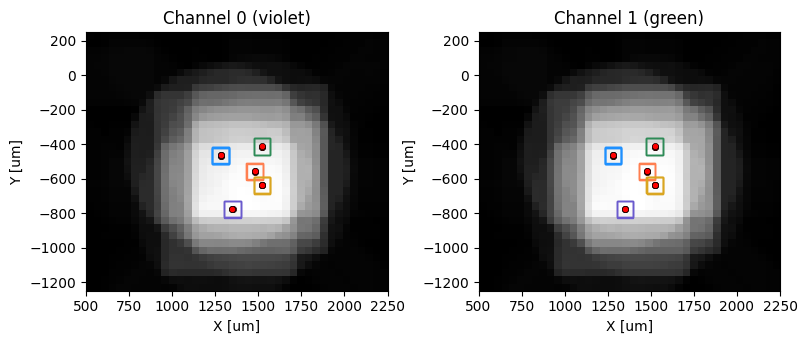

{'t0_s': [2064.0, 3114.0, 4469.0, 5611.0, 7379.0], 't1_s': [3025.0, 4279.0, 5417.0, 6837.0, 8316.0], 'fID': [0, 1, 2, 3, 4]}


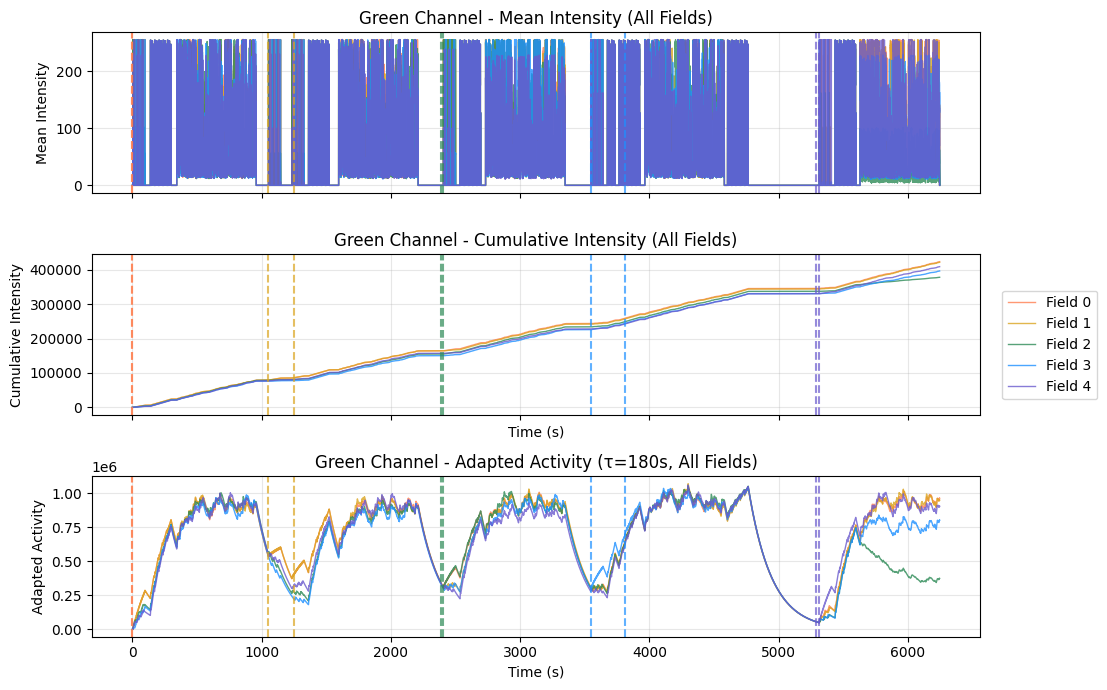

In [188]:
#movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[ 7,  9]) # F0
#movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[10, 13],) # F1
#movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[16, 18]) # F2
#movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[20, 24]) # F3
#movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[28, 30]) # F4

movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[ 7, 30]) # all fields
#movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[18, 20]) 
calc_temporal_exposure(movie_data, params)